**Notebook for converting DNAforge outputs (oxDNA file format) into ENSnano inputs (ENS file format)**

Author: Elina Heikkilä

Report bugs to: elina.s.heikkila@aalto.fi

In [1]:
# install required packages if not yet installed

#!pip install numpy
#!pip install matplotlib
#!pip install progressbar2

In [2]:
# in case jupyter doesn't find the packages

# import sys
# sys.path.append("path/to/python/site-packages")

In [3]:
%matplotlib notebook

import json

from operator import itemgetter, methodcaller

import numpy as np
import matplotlib.pyplot as plt
import progressbar

**Step 1: Give user inputs**

*Modify the contents of this cell.*

In [4]:
fname_top = "at_torus.top"
    # the name of the oxDNA topology file
    # place this file to the notebook directory
    
fname_conf = "at_torus.conf"
    # the name of the oxDNA configuration file
    # place this file to the notebook directory

oxdna_format = "classic"
    # classic:   topology file gives strands in the 3'->5' direction
    # new:   topology file gives strands in the 5'->3' direction

fname_ens = "at_torus.ens"
    # the name of the output file
    # will be written to the notebook directory

**Class for handling helical segments and helper functions**

*Don't modify unless necessary.*

In [5]:
class Helix:

    
    def __init__(self, start_nt):
        # row index 1: base normal vectors point in the direction of decreasing column index
        # row index 2: base normal vectors point in the direction of increasing column index
        self.content = np.zeros((2, 1))
        self.content[0, 0] = int(start_nt)

        
    def get_content(self):
        return self.content

    
    def overwrite_content(self, new_content):
        self.content = new_content
        
        
    def get_length(self):
        return np.shape(self.content)[1]

        
    def merge_perpendicular(self, base_nt, hits, helices):
        for hit in hits:
            new_nt = hit[0]
            other_helix = hit[1]
            
            if not self is other_helix:
                
                a1 = self.content
                a2 = other_helix.get_content()
                index_set_orig = a1[np.where(a1 > 0)].flatten().tolist() + a2[np.where(a2 > 0)].flatten().tolist()
                loc1 = np.argwhere(a1 == base_nt)[0]
                loc2 = np.argwhere(a2 == new_nt)[0]
        
                if loc1[0] == loc2[0]:
                    a2 = np.flip(a2)
                    loc2 = np.argwhere(a2 == new_nt)[0]
        
                d1 = np.shape(a1)[1]
                d2 = np.shape(a2)[1]
                a_12 = np.zeros((2, 1 + max([loc1[1], loc2[1]]) + max([d1-loc1[1]-1, d2-loc2[1]-1])))
                loc_12 = max([loc1[1], loc2[1]])
        
                if loc_12 == loc1[1]:
                    a_12[:, 0:d1] = np.add(a_12[:, 0:d1], a1)
                else:
                    a_12[:, loc_12-loc1[1]:loc_12-loc1[1]+d1] = np.add(a_12[:, loc_12-loc1[1]:loc_12-loc1[1]+d1], a1)
        
                if loc_12 == loc2[1]:
                    a_12[:, 0:d2] = np.add(a_12[:, 0:d2], a2)
                else:
                    a_12[:, loc_12-loc2[1]:loc_12-loc2[1]+d2] = np.add(a_12[:, loc_12-loc2[1]:loc_12-loc2[1]+d2], a2)
        
                index_set_new = a_12[np.where(a_12 > 0)].flatten().tolist()
        
                index_set_orig.sort()
                index_set_new.sort()
    
                if index_set_orig == index_set_new:
                    merged_helix = Helix(0)
                    merged_helix.overwrite_content(a_12)
                    updated_helices = []
                    updated_helices.append(merged_helix)
                    for helix in helices:
                        if (not helix is self) and (not helix is other_helix):
                            updated_helices.append(helix)
                    return updated_helices, True
        else:
            return helices, False
        
    
    def merge_parallel(self, base_nt, hits, helices):
        for hit in hits:
            new_nt = hit[0]
            other_helix = hit[1]
        
            if not self is other_helix:
        
                a1 = self.content
                a2 = other_helix.get_content()
                index_set_orig = a1[np.where(a1 > 0)].flatten().tolist() + a2[np.where(a2 > 0)].flatten().tolist()
                loc1 = np.argwhere(a1 == base_nt)[0]
                loc2 = np.argwhere(a2 == new_nt)[0]
        
                if loc1[0] != 0:
                    a1 = np.flip(a1)
                    loc1 = np.argwhere(a1 == base_nt)[0]
            
                if loc1[0] != loc2[0]:
                    a2 = np.flip(a2)
                    loc2 = np.argwhere(a2 == new_nt)[0]
            
                # new is always on the opposite of base normal side of base
                # 5'-3' direction
                d1 = np.shape(a1)[1]
                d2 = np.shape(a2)[1]
                a_12 = np.zeros((2, 1 + max([loc1[1], loc2[1]-1]) + max([d1-loc1[1]-1, d2-loc2[1]])))
                loc_12 = max([loc1[1], loc2[1]-1])
        
                if loc_12 == loc1[1]:
                    a_12[:, 0:d1] = np.add(a_12[:, 0:d1], a1)
                else:
                    a_12[:, loc_12-loc1[1]-1:loc_12-loc1[1]+d1-1] = np.add(a_12[:, loc_12-loc1[1]-1:loc_12-loc1[1]+d1-1], a1)
        
                if loc_12 == loc2[1]-1:
                    a_12[:, 0:d2] = np.add(a_12[:, 0:d2], a2)
                else:
                    a_12[:, loc_12-loc2[1]+1:loc_12-loc2[1]+d2+1] = np.add(a_12[:, loc_12-loc2[1]+1:loc_12-loc2[1]+d2+1], a2)
        
                index_set_new = a_12[np.where(a_12 > 0)].flatten().tolist()
        
                index_set_orig.sort()
                index_set_new.sort()
        
                if index_set_orig == index_set_new:
                    merged_helix = Helix(0)
                    merged_helix.overwrite_content(a_12)
                    updated_helices = []
                    updated_helices.append(merged_helix)
                    for helix in helices:
                        if (not helix is self) and (not helix is other_helix):
                            updated_helices.append(helix)
                    return updated_helices, True
                
        else:
            return helices, False

In [6]:
def read_nucleotides(fname_conf):
    with open(fname_conf, "r") as f:
        lines = f.readlines()
        lines = lines[0+3: len(lines)]
        nts = np.zeros((len(lines), 3*3))
        for i, line in enumerate(lines):
            vec = line.split(" ")
            if len(vec) >= 9:
                nts[i, :] = vec[0:3*3]
            else:
                print("Information missing for nucleotide {}. Check configuration file.\n".format(i))
        com = np.mean(nts[:, 0:3], axis=0)
        nts[:, 0:3] = nts[:, 0:3] - np.tile(com, (np.shape(nts)[0], 1))
        return nts


def check_lower_bound(helices, min_edge):
    for helix in helices:
        if helix.get_length() < min_edge:
            return False
    return True


def find_helix(nt, helices):
    for helix in helices:
        content = helix.get_content()
        if len(np.argwhere(content == nt)) != 0:
            return helix
    print(len(helices))
    for helix in helices:
        content = helix.get_content()
        print(content)
    print("Failed to find the helix for nucleotide {}.".format(nt))
    return 0


def check_hb_pos(nts, base_nt, fit_tol, helices):
    # hb pos is at r_base_nt + A*e1 + B*e2 + C*e3, using the reference frame of base nt
    A = 1.2
    B = 0
    C = 0
    base_nt = int(base_nt-1)
    e1 = nts[base_nt, 3:6]
    e3 = nts[base_nt, 6:9]
    e2 = np.linalg.cross(e3, e1)
    hb_pos = nts[base_nt, 0:3] + A*e1 + B*e2 + C*e3
    hits = []
    for i in range(np.shape(nts)[0]):
        d = np.sqrt(np.sum(np.pow(nts[i, 0:3] - hb_pos, 2)))
        if d <= fit_tol and i != base_nt:
            d2 = np.sqrt(np.sum(np.pow(nts[i, 0:3] - nts[base_nt, 0:3], 2)))
            hits.append((i+1, find_helix(i+1, helices), d2))
    if len(hits) > 0:
        hits = sorted(hits, key=itemgetter(2))
        return True, hits
    else:
        return False, hits


def check_perpendicular(nts, base_helix, fit_tol, helices):
    base_array = base_helix.get_content()
    for i in range(base_helix.get_length()):
        if base_array[0, i] == 0 and base_array[1, i] != 0:
            found, hits = check_hb_pos(nts, base_array[1, i], fit_tol, helices)
            if found:
                new_helices, valid = base_helix.merge_perpendicular(base_array[1, i], hits, helices)
                if valid:
                    return found, new_helices
        if base_array[1, i] == 0 and base_array[0, i] != 0:
            found, hits = check_hb_pos(nts, base_array[0, i], fit_tol, helices)
            if found:
                new_helices, valid = base_helix.merge_perpendicular(base_array[0, i], hits, helices)
                if valid:
                    return found, new_helices
    return False, helices


def check_bb_pos(nts, base_nt, fit_tol, helices):
    # check only the (opposite of) base normal side
    # bb pos is at r_base_nt + A*e1 + B*e2 + C*e3, using the reference frame of base nt
    A = 0.11397501826286316
    B = 0.3518234193325043
    C = -0.38976284861564636
    base_nt = int(base_nt-1)
    e1 = nts[base_nt, 3:6]
    e3 = nts[base_nt, 6:9]
    e2 = np.linalg.cross(e3, e1)
    bb_pos = nts[base_nt, 0:3] + A*e1 + B*e2 + C*e3
    hits = []
    for i in range(np.shape(nts)[0]):
        d = np.sqrt(np.sum(np.pow(nts[i, 0:3] - bb_pos, 2)))
        if d <= fit_tol and i != base_nt:
            d2 = np.sqrt(np.sum(np.pow(nts[i, 0:3] - nts[base_nt, 0:3], 2)))
            hits.append((i+1, find_helix(i+1, helices), d2))
    if len(hits) > 0:
        hits = sorted(hits, key=itemgetter(2))
        return True, hits
    else:
        return False, hits


def check_parallel(nts, base_helix, fit_tol, helices):
    base_array = base_helix.get_content()
    for i in range(1, base_helix.get_length()-1):
        if base_array[0, i+1] == 0 and base_array[0, i] != 0:
            found, hits = check_bb_pos(nts, base_array[0, i], fit_tol, helices)
            if found:
                new_helices, valid = base_helix.merge_parallel(base_array[0, i], hits, helices)
                if valid:
                    return found, new_helices
        if base_array[1, i-1] == 0 and base_array[1, i] != 0:
            found, hits = check_bb_pos(nts, base_array[1, i], fit_tol, helices)
            if found:
                new_helices, valid = base_helix.merge_parallel(base_array[1, i], hits, helices)
                if valid:
                    return found, helices
    if base_array[0, base_helix.get_length()-1] != 0:
        found, hits = check_bb_pos(nts, base_array[0, base_helix.get_length()-1], fit_tol, helices)
        if found:
            new_helices, valid = base_helix.merge_parallel(base_array[0, base_helix.get_length()-1], hits, helices)
            if valid:
                return found, new_helices
    if base_array[1, 0] != 0:
        found, hits = check_bb_pos(nts, base_array[1, 0], fit_tol, helices)
        if found:
            new_helices, valid = base_helix.merge_parallel(base_array[1, 0], hits, helices)
            if valid:
                return found, new_helices
    return False, helices


def plot_helices(nts, helices, show_numbers, n):
    # plot intermediate steps, for debugging purposes
    fig = plt.figure();
    ax = fig.add_subplot(projection='3d');
    for helix in helices:
        content = helix.get_content()
        nt_pos = np.zeros((3, np.count_nonzero(content)))
        write_pos = 0
        for i in range(np.shape(content)[1]):
            if content[0, i] != 0:
                nt_pos[:, write_pos] = nts[int(content[0, i])-1, 0:3]
                if show_numbers:
                    ax.text(nt_pos[0, write_pos], nt_pos[1, write_pos], nt_pos[2, write_pos], str(int(content[0, i])), color="black")
                write_pos = write_pos + 1
        for j in range(np.shape(content)[1]):
            if content[1, j] != 0:
                nt_pos[:, write_pos] = nts[int(content[1, j])-1, 0:3]
                if show_numbers:
                    ax.text(nt_pos[0, write_pos], nt_pos[1, write_pos], nt_pos[2, write_pos], str(int(content[1, j])), color="black")
                write_pos = write_pos + 1
        ax.scatter(nt_pos[0, :], nt_pos[1, :], nt_pos[2, :]);
    ax.set_xlabel('X');
    ax.set_ylabel('Y');
    ax.set_zlabel('Z');
    plt.savefig("checkpoint{}".format(n));
    plt.close();


def merge_helices(nts, helices, fit_tol_perp, fit_tol_par, b):
    stop = False
    while not stop:
        b.update(np.shape(nts)[0] - len(helices))
        # plot intermediate steps, for debugging purposes
        # if (int(np.shape(nts)[0]) - len(helices)) % 200 == 0:
        #    plot_helices(nts, helices, False, np.shape(nts)[0] - len(helices))
        for helix in helices:
            found, helices = check_perpendicular(nts, helix, fit_tol_perp, helices)
            if found:
                break
            found, helices = check_parallel(nts, helix, fit_tol_par, helices)
            if found:
                break
        else:
            stop = True
    return helices


def force_merge(nts, helices, fit_tol_perp, fit_tol_par, fit_tol_step):
    found = False
    while not found:
        base_helix = helices[0]
        found, new_helices = check_perpendicular(nts, base_helix, fit_tol_perp, helices)
        if not found:
            found, new_helices = check_parallel(nts, base_helix, fit_tol_par, helices)
        fit_tol_perp = fit_tol_perp + fit_tol_step
        fit_tol_par = fit_tol_par + fit_tol_step
    return new_helices


def init_helices(nts):
    n_nt = np.shape(nts)[0]
    helices = [Helix(i) for i in range(1, n_nt+1)]
    return helices


def postprocess_helices(nts, helices, edge_count, b, fit_tol_perp, fit_tol_par, fit_tol_step):
    start = len(helices)
    while len(helices) > edge_count:
        b.update(start - len(helices))
        helices = sorted(helices, key=methodcaller('get_length'))
        helices = force_merge(nts, helices, fit_tol_perp, fit_tol_par, fit_tol_step)
    return helices

**Step 2(a): Solve for ENS helices: Find long edge segments**

*Modify tolerances if necessary.*

Here we try to determine how the nucleotides should be categorized into helical segments for the purpose of getting a clean 2D sheet view in ENSnano. First, the automatic search starts with each nucleotide in its own segment and merges segments based on the compatibility of their spatial positions, given by the .conf file.

The problem here is that vertices commonly contain nucleotides whose positions are different than the B-form standard positions. For now, we leave them in their own segments, and focus on finding the edge segments that closely follow B-form.

In [7]:
nts = read_nucleotides(fname_conf)
print("The structure has {} nucleotides.".format(np.shape(nts)[0]))

# adjust tolerances manually if merging doesn't behave as desired
fit_tol_perp = 0.3
fit_tol_par = 0.1

print("Merging helices with tolerances {} and {}...".format(fit_tol_perp, fit_tol_par))

b = progressbar.ProgressBar(maxval=np.shape(nts)[0])
b.start()

helices = init_helices(nts)
helices = merge_helices(nts, helices, fit_tol_perp, fit_tol_par, b)

b.finish()

print("Final number of helical segments to be treated as edge components is {}.".format(len(helices)))
print("Adjust fit tolerances if necessary.")

  0% (7 of 4220) |                       | Elapsed Time: 0:00:00 ETA:   0:01:10

The structure has 4220 nucleotides.
Merging helices with tolerances 0.3 and 0.1...


100% (4220 of 4220) |####################| Elapsed Time: 0:05:14 Time:  0:05:142422


Final number of helical segments to be treated as edge components is 313.
Adjust fit tolerances if necessary.


**Step 2(b): Solve for ENS helices: Force vertex segments into edges**

*Modify tolerances if necessary.*

Here we push the vertex nucleotides into edge helices by forcing the merges even if B-form is not adhered to. This is done by using larger tolerance values and explicitly specifying the final number of helices we want in the 2D sheet view ("edge count").

In [8]:
b = progressbar.ProgressBar(maxval=len(helices))
b.start()

# adjust tolerances manually if merging doesn't behave as desired
fit_tol_perp = 0.5
fit_tol_par = 0.5

fit_tol_step = 0.1

edge_count = 50
# use 50 for at torus
# use 18 for st bipyramid
# use 12 for st tetrahedron (8 for at tetrahedron)
# use 24 for st cube
helices = postprocess_helices(nts, helices, edge_count, b, fit_tol_perp, fit_tol_par, fit_tol_step)

b.finish()

100% (313 of 313) |######################| Elapsed Time: 0:00:12 Time:  0:00:120:02


**Step 3: Inspect helices and redo Step 2 with new parameters if necessary**

*Plotting style can be customized freely.*

<IPython.core.display.Javascript object>


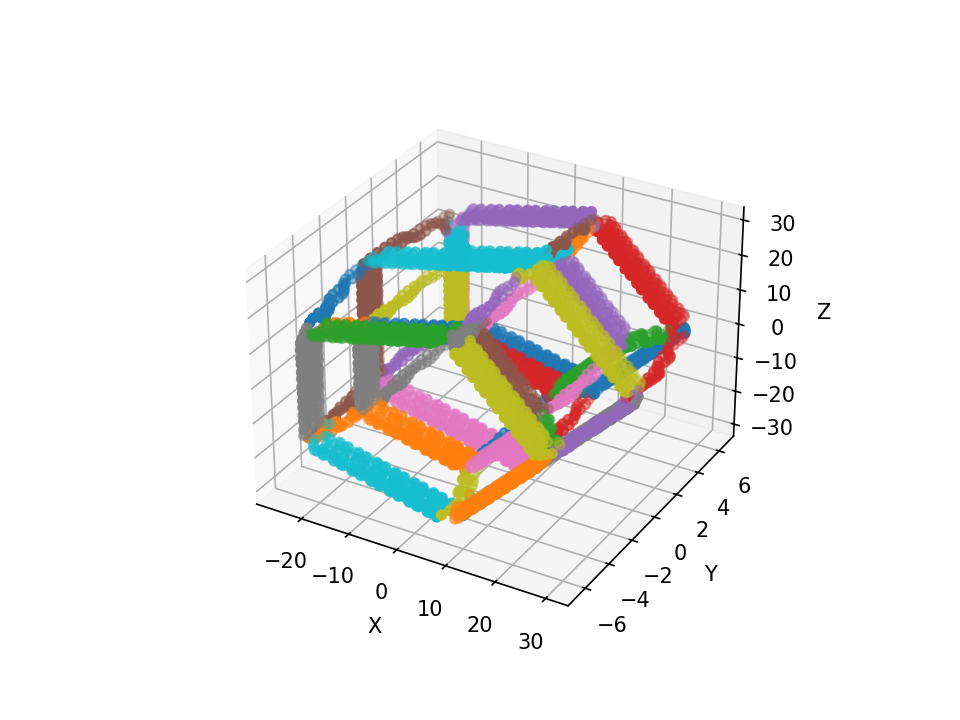

In [9]:
def plot_helices(nts, helices, show_numbers):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    for helix in helices:
        content = helix.get_content()
        nt_pos = np.zeros((3, np.count_nonzero(content)))
        write_pos = 0
        for i in range(np.shape(content)[1]):
            if content[0, i] != 0:
                nt_pos[:, write_pos] = nts[int(content[0, i])-1, 0:3]
                if show_numbers:
                    ax.text(nt_pos[0, write_pos], nt_pos[1, write_pos], nt_pos[2, write_pos], str(int(content[0, i])), color="black")
                write_pos = write_pos + 1
        for j in range(np.shape(content)[1]):
            if content[1, j] != 0:
                nt_pos[:, write_pos] = nts[int(content[1, j])-1, 0:3]
                if show_numbers:
                    ax.text(nt_pos[0, write_pos], nt_pos[1, write_pos], nt_pos[2, write_pos], str(int(content[1, j])), color="black")
                write_pos = write_pos + 1
        ax.scatter(nt_pos[0, :], nt_pos[1, :], nt_pos[2, :])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


plot_helices(nts, helices, show_numbers=False)

**Helper functions for output file writing and .top file reading**

*No big modifications should be needed here.*

For non-standard DNA parameters, modify "write_dna_parameters" function. For a different start position in the 3D view, modify "write camera" function.

In [10]:
def vec_to_rotor(v):
    """ Transform a vector v = (x , y , z ) to a rotor
    describing the rotation from the x - axis
    to the vector
    Adapted from the original source:
    Nicolas Levy, Nicolas Schabanel.
    ENSnano: a 3D modeling software for DNA nanostructures.
    DNA27 - 27th International Conference on DNA Computing and Molecular Programming, Sep 2021, Oxford, France.
    """
    v_norm = np.linalg.norm(v)
    v_hat = v / v_norm
    s = 1 + v_hat[0]
    norm_bv = np.sqrt(v_hat[2]*v_hat[2] + v_hat[1]*v_hat[1])
    if norm_bv < 1e-5:
        if v_hat[0] > 0:
            return np.array([1, 0, 0, 0])
        else:
            return np.array([0, 1, 0, 0])
    norm = np.sqrt(v_hat[2]*v_hat[2] + v_hat[1]*v_hat[1] + s*s)
    return np.array([s/norm, -v_hat[1]/norm, -v_hat[2]/norm, 0])


def rotor_operate(r, vec):
    # no normalization here, assuming that r was formed from vectors with norm one
    S_x = r[0]*vec[0] + r[1]*vec[1] + r[2]*vec[2]
    S_y = r[0]*vec[1] - r[1]*vec[0] + r[3]*vec[2]
    S_z = r[0]*vec[2] - r[2]*vec[0] - r[3]*vec[1]
    S_xyz = r[1]*vec[2] + r[2]*vec[1] + r[3]*vec[0]
    # scalar is rotor 0
    # xy is rotor 1
    # xz is rotor 2
    # yz is rotor 3
    result = np.zeros((1, 3))
    result[0, 0] = S_x*r[0] + S_y*r[1] + S_z*r[2] + S_xyz*r[3]
    result[0, 1] = -S_x*r[1] + S_y*r[0] + S_z*r[3] + S_xyz*r[2]
    result[0, 2] = -S_x*r[2] - S_y*r[3] + S_z*r[0] + S_xyz*r[1]
    return result


def gram_schmidt_3d(e1):
    e1 = e1 / np.linalg.norm(e1)
    try:
        e2 = e1 + np.array([0, 0, 1])
        e2 = e2 - np.dot(e2, e1) * e1
        e2 = e2 / np.linalg.norm(e2)
    except ZeroDivisionError:
        try:
            e2 = e1 + np.array([0, 1, 0])
            e2 = e2 - np.dot(e2, e1) * e1
            e2 = e2 / np.linalg.norm(e2)
        except ZeroDivisionError:
            try:
                e2 = e1 + np.array([1, 0, 0])
                e2 = e2 - np.dot(e2, e1) * e1
                e2 = e2 / np.linalg.norm(e2)
            except ZeroDivisionError:
                print("Failed to find a Bezier plane basis. Check helix vectors.")
                return np.array([0,0,0])
    return e2


def write_helices(nts, helices, ens_dict):
    for i, helix in enumerate(helices):
        ens_dict["helices"][str(i+1)] = {}
        content = helix.get_content()
        # write start position
        top_nz = content[0, np.where(content[0, :] > 0)].astype(np.int32)[0]
        start_top = top_nz[0]-1
        end_top = top_nz[-1]-1
        mean_top = np.mean(nts[top_nz-1, 0:3], axis=0)
        bottom_nz = content[1, np.where(content[1, :] > 0)].astype(np.int32)[0]
        start_bottom = bottom_nz[0]-1
        end_bottom = bottom_nz[-1]-1
        mean_bottom = np.mean(nts[bottom_nz-1, 0:3], axis=0)
        start_pos = (1/2)*(nts[start_top, 0:3] + nts[start_bottom, 0:3])
        end_pos = (1/2)*(nts[end_top, 0:3] + nts[end_bottom, 0:3])
        ens_dict["helices"][str(i+1)]["position"] = {}
        ens_dict["helices"][str(i+1)]["position"]["x"] = start_pos[0]
        ens_dict["helices"][str(i+1)]["position"]["y"] = start_pos[1]
        ens_dict["helices"][str(i+1)]["position"]["z"] = start_pos[2]
        # orientations are stored as rotors
        helix_vec1 = nts[end_top, 0:3] - nts[start_top, 0:3]
        helix_vec2 = nts[end_bottom, 0:3] - nts[start_bottom, 0:3]
        helix_vec = (1/2)*(helix_vec1 + helix_vec2)
        helix_vec = helix_vec / np.linalg.norm(helix_vec)
        rotor = vec_to_rotor(helix_vec)
        ens_dict["helices"][str(i+1)]["orientation"] = {}
        ens_dict["helices"][str(i+1)]["orientation"]["s"] = rotor[0]
        ens_dict["helices"][str(i+1)]["orientation"]["bv"] = {}
        ens_dict["helices"][str(i+1)]["orientation"]["bv"]["xy"] = rotor[1]
        ens_dict["helices"][str(i+1)]["orientation"]["bv"]["xz"] = rotor[2]
        ens_dict["helices"][str(i+1)]["orientation"]["bv"]["yz"] = rotor[3]
        # create a bezier grid for each vertex
        ens_dict["helices"][str(i+1)]["grid_position"] = {}
        ens_dict["helices"][str(i+1)]["grid_position"]["grid"] = {}
        ens_dict["helices"][str(i+1)]["grid_position"]["grid"]["BezierPathGrid"] = {} 
        ens_dict["helices"][str(i+1)]["grid_position"]["grid"]["BezierPathGrid"]["path_id"] = i
        ens_dict["helices"][str(i+1)]["grid_position"]["grid"]["BezierPathGrid"]["vertex_id"] = 1
        ens_dict["helices"][str(i+1)]["grid_position"]["x"] = 0
        ens_dict["helices"][str(i+1)]["grid_position"]["y"] = 0
        ens_dict["helices"][str(i+1)]["grid_position"]["axis_pos"] = 0
        ens_dict["helices"][str(i+1)]["grid_position"]["roll"] = 0.0
        # position and orientation of the helix in the 2D view
        ens_dict["helices"][str(i+1)]["isometry2d"] = {}
        ens_dict["helices"][str(i+1)]["isometry2d"]["translation"] = {}
        ens_dict["helices"][str(i+1)]["isometry2d"]["translation"]["x"] = 0.0
        ens_dict["helices"][str(i+1)]["isometry2d"]["translation"]["y"] = 0.0 + i*10.0
        ens_dict["helices"][str(i+1)]["isometry2d"]["rotation"] = {}
        ens_dict["helices"][str(i+1)]["isometry2d"]["rotation"]["s"] = 1.0
        ens_dict["helices"][str(i+1)]["isometry2d"]["rotation"]["bv"] = {}
        ens_dict["helices"][str(i+1)]["isometry2d"]["rotation"]["bv"]["xy"] = 0.0
        # other helix settings
        ens_dict["helices"][str(i+1)]["symmetry"] = {}
        ens_dict["helices"][str(i+1)]["symmetry"]["x"] = 1.0
        ens_dict["helices"][str(i+1)]["symmetry"]["y"] = 1.0
        ens_dict["helices"][str(i+1)]["roll"] = 0.0
        ens_dict["helices"][str(i+1)]["curve"] = {}
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"] = {}
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"]["path_id"] = i
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"]["translation"] = {}
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"]["translation"]["x"] = 0.0
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"]["translation"]["y"] = 0.0
        ens_dict["helices"][str(i+1)]["curve"]["TranslatedPath"]["translation"]["z"] = 0.0
        ens_dict["helices"][str(i+1)]["path_id"] = i
        # write a separate bezier plane for each helix
        # plane normal vector is orthogonal to helix vector --> helix lies in bezier plane
        # local basis:
        # e1 = normalized helix vector
        # e3 = bezier plane normal vector
        e2 = gram_schmidt_3d(helix_vec)
        e1_rotor = vec_to_rotor(helix_vec)
        e2_rotor = vec_to_rotor(e2)
        e3 = np.linalg.cross(helix_vec, e2)
        e3_rotor = vec_to_rotor(e3)
        ens_dict["bezier_planes"][str(i)] = {}
        ens_dict["bezier_planes"][str(i)]["position"] = {}
        ens_dict["bezier_planes"][str(i)]["position"]["x"] = start_pos[0]
        ens_dict["bezier_planes"][str(i)]["position"]["y"] = start_pos[1]
        ens_dict["bezier_planes"][str(i)]["position"]["z"] = start_pos[2]
        ens_dict["bezier_planes"][str(i)]["orientation"] = {}
        ens_dict["bezier_planes"][str(i)]["orientation"]["s"] = e3_rotor[0]
        ens_dict["bezier_planes"][str(i)]["orientation"]["bv"] = {}
        ens_dict["bezier_planes"][str(i)]["orientation"]["bv"]["xy"] = e3_rotor[1]
        ens_dict["bezier_planes"][str(i)]["orientation"]["bv"]["xz"] = e3_rotor[2]
        ens_dict["bezier_planes"][str(i)]["orientation"]["bv"]["yz"] = e3_rotor[3]
        # write a separate bezier path for each helix
        ens_dict["bezier_paths"][str(i)] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"] = [{}, {}]
        # start vertex: at bezier plane origin
        # end vertex location: helix vector projected to bezier basis
        r_end = (-1)*start_pos + end_pos
        r_end = np.reshape(r_end, (1, 3))
        # operate on cartesian basis with the e3 rotor
        bez_ez = rotor_operate(e3_rotor, np.array([1, 0, 0]))
        bez_ey = rotor_operate(e3_rotor, np.array([0, 1, 0]))
        bez_ex = rotor_operate(e3_rotor, np.array([0, 0, 1]))
        # project to bezier basis and scale
        bez_x = np.linalg.vecdot(r_end, bez_ex)
        bez_y = np.linalg.vecdot(r_end, bez_ey)
        bez_z = np.linalg.vecdot(r_end, bez_ez)
        bez_norm = np.sqrt(bez_x[0]**2 + bez_y[0]**2)
        scale = np.linalg.norm(r_end)/bez_norm
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["plane_id"] = i
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position"]["x"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position"]["y"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_in"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_in"]["x"] = -0.5*scale*bez_x[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_in"]["y"] = -0.5*scale*bez_y[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_out"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_out"]["x"] = 0.5*scale*bez_x[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["position_out"]["y"] = 0.5*scale*bez_y[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["grid_translation"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["grid_translation"]["x"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["grid_translation"]["y"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["grid_translation"]["z"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][0]["angle_with_plane"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["plane_id"] = i
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position"]["x"] = scale*bez_x[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position"]["y"] = scale*bez_y[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_in"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_in"]["x"] = 0.5*scale*bez_x[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_in"]["y"] = 0.5*scale*bez_y[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_out"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_out"]["x"] = 1.5*scale*bez_x[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["position_out"]["y"] = 1.5*scale*bez_y[0]
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["grid_translation"] = {}
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["grid_translation"]["x"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["grid_translation"]["y"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["grid_translation"]["z"] = 0.0
        ens_dict["bezier_paths"][str(i)]["vertices"][1]["angle_with_plane"] = 0.0
        # other bezier settings
        ens_dict["bezier_paths"][str(i)]["is_cyclic"] = False
        ens_dict["bezier_paths"][str(i)]["grid_type"] = {}
        ens_dict["bezier_paths"][str(i)]["grid_type"]["Square"] = {}
    return ens_dict
        

def parse_classic(lines, Ns, Nt):
    # classic: 3'->5'
    strands = np.zeros((Ns, Nt))
    sequences = np.empty((Ns, Nt), dtype=np.str_)
    S_prev = -1
    S_pos = 0
    for i, line in enumerate(lines):
        S, B, three, five = line.split(" ")
        S = int(S)
        if S == S_prev:
            S_pos = S_pos + 1
        else:
            S_pos = 0
        strands[S-1, S_pos] = i + 1
        sequences[S-1, S_pos] = B
        S_prev = S
    np.flip(strands, axis=1)
    return strands, sequences


def parse_new(lines, Ns, Nt):
    # new: 5'->3'
    strands = np.zeros((Ns, Nt))
    sequences = np.empty((Ns, Nt), dtype=np.str_)
    nt_count = 1
    for i, line in enumerate(lines):
        for j in range(len(line)):
            strands[i, j] = nt_count
            sequences[i, j] = line[j]
            nt_count = nt_count + 1
    return strands, sequences


def read_strands(fname_top, oxdna_format):
    with open(fname_top, "r") as f:
        lines = f.readlines()
        Nt, Ns = lines[0].split(" ")
        Nt = int(Nt)
        Ns = int(Ns)
        lines = lines[1:len(lines)]
        if oxdna_format == "classic":
            strands = parse_classic(lines, Ns, Nt)
        else:
            strands = parse_new(lines, Ns, Nt)
    return strands


def write_strands(nts, helices, strands, sequences, ens_dict):
    xover_ind = 0
    for i in range(np.shape(strands)[0]):
        ens_dict["strands"][str(i)] = {}
        ens_dict["strands"][str(i)]["domains"] = []
        ens_dict["strands"][str(i)]["junctions"] = []
        # read along strand
        prev_helix = -1
        domain_ind = -1
        prev_nt = -1
        for k, j in enumerate(strands[i, :]):
            if j != 0:
                # find helix for nucleotide
                helix = find_helix(j, helices)
                h_ind = helices.index(helix) + 1
                # find helix index (2D sheet index) for nucleotide
                nt_array = helix.get_content()
                nt_ind = np.argwhere(nt_array == j)[0][1]
                if h_ind != prev_helix:
                    prev_helix = h_ind
                    # init new domain
                    domain_ind = domain_ind + 1
                    ens_dict["strands"][str(i)]["domains"].append({})
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"] = {}
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["helix"] = int(h_ind)
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["start"] = int(nt_ind)
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["sequence"] = str(sequences[i, k])
                    if domain_ind > 0:
                        ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["end"] = int(prev_nt)
                        if int(prev_nt) < ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["start"]:
                            ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["end"] = ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["start"]
                            ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["start"] = int(prev_nt)
                            ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["forward"] = False
                        else:
                            ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["forward"] = True
                        ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["end"] = ens_dict["strands"][str(i)]["domains"][domain_ind-1]["HelixDomain"]["end"] + 1
                    # place crossover
                    ens_dict["strands"][str(i)]["junctions"].append({"IdentifiedXover": xover_ind})
                    xover_ind = xover_ind + 1
                else:
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["sequence"] = ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["sequence"] + str(sequences[i, k])
                prev_nt = nt_ind
            else:
                # end strand
                ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["end"] = int(prev_nt)
                if int(prev_nt) < ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["start"]:
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["end"] = ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["start"]
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["start"] = int(prev_nt)
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["forward"] = False
                else:
                    ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["forward"] = True
                ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["end"] = ens_dict["strands"][str(i)]["domains"][domain_ind]["HelixDomain"]["end"] + 1
                ens_dict["strands"][str(i)]["junctions"].append("Prime3")
                break
    return ens_dict


def write_dna_parameters(ens_dict):
    ens_dict["dna_parameters"]["rise"] = 0.332
    ens_dict["dna_parameters"]["helix_radius"] = 0.93
    ens_dict["dna_parameters"]["bases_per_turn"] = 10.44
    ens_dict["dna_parameters"]["groove_angle"] = 2.3722034
    ens_dict["dna_parameters"]["inter_helix_gap"] = 0.7900001
    ens_dict["dna_parameters"]["inclination"] = 0.043000013
    return ens_dict


def write_camera(nts, ens_dict):
    # front view, facing xy plane, 100 units away
    ens_dict["saved_camera"]["position"] = {}
    ens_dict["saved_camera"]["position"]["x"] = 0.0
    ens_dict["saved_camera"]["position"]["y"] = 0.0
    ens_dict["saved_camera"]["position"]["z"] = 100.0
    ens_dict["saved_camera"]["orientation"] = {}
    ens_dict["saved_camera"]["orientation"]["s"] = 1.0
    ens_dict["saved_camera"]["orientation"]["bv"] = {}
    ens_dict["saved_camera"]["orientation"]["bv"]["xy"] = 0.0
    ens_dict["saved_camera"]["orientation"]["bv"]["xz"] = 0.0
    ens_dict["saved_camera"]["orientation"]["bv"]["yz"] = 0.0
    ens_dict["saved_camera"]["name"] = "Saved Camera"
    ens_dict["saved_camera"]["id"] = 0
    ens_dict["saved_camera"]["pivot_position"] = {}
    ens_dict["saved_camera"]["pivot_position"]["x"] = 0.0
    ens_dict["saved_camera"]["pivot_position"]["y"] = 0.0
    ens_dict["saved_camera"]["pivot_position"]["z"] = 0.0
    return ens_dict

**Step 4: Write final output**

*No modifications should be needed*

In [11]:
# initialize output file content
ens_dict = {"helices": {},
            "strands": {},
            "dna_parameters": {},
            "free_grids": {},
            "ensnano_version": "0.7.2",
            "saved_camera": {},
            "rainbow_scaffold": False,
            "bezier_planes": {},
            "bezier_paths": {},
            "external_3d_objects": {},
            "clone_isometries": []
           }

ens_dict = write_helices(nts, helices, ens_dict)

strands, sequences = read_strands(fname_top, oxdna_format)
# always in 5'-3' direction
ens_dict = write_strands(nts, helices, strands, sequences, ens_dict)

ens_dict = write_dna_parameters(ens_dict)
ens_dict = write_camera(nts, ens_dict)

# write output file
with open(fname_ens, "w") as f:
    json.dump(ens_dict, f, indent=1)